1. Understand the Dataset

In [1]:
# 1.1 Import the dataset
import pandas as pd
df=pd.read_csv("C:/Users/shree/Downloads/311_Service_Requests_from_2010_to_Present.csv")

C:\Users\Ganesh\AppData\Local\Temp\ipykernel_18352\909477471.py:3: DtypeWarning: Columns (48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("C:/Users/Ganesh/Downloads/311_Service_Requests_from_2010_to_Present.csv")


In [2]:
# 1.2 Visualize the dataset
df.head()

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Garage Lot Name,Ferry Direction,Ferry Terminal Name,Latitude,Longitude,Location
0,32310363,12/31/2015 11:59:45 PM,01/01/2016 12:55:15 AM,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10034.0,71 VERMILYEA AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.865682,-73.923501,"(40.86568153633767, -73.92350095571744)"
1,32309934,12/31/2015 11:59:44 PM,01/01/2016 01:26:57 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11105.0,27-07 23 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.775945,-73.915094,"(40.775945312321085, -73.91509393898605)"
2,32309159,12/31/2015 11:59:29 PM,01/01/2016 04:51:03 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,10458.0,2897 VALENTINE AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.870325,-73.888525,"(40.870324522111424, -73.88852464418646)"
3,32305098,12/31/2015 11:57:46 PM,01/01/2016 07:43:13 AM,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,10461.0,2940 BAISLEY AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.835994,-73.828379,"(40.83599404683083, -73.82837939584206)"
4,32306529,12/31/2015 11:56:58 PM,01/01/2016 03:24:42 AM,NYPD,New York City Police Department,Illegal Parking,Blocked Sidewalk,Street/Sidewalk,11373.0,87-14 57 ROAD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.733060,-73.874170,"(40.733059618956815, -73.87416975810375)"


In [3]:
# 1.3 Print the columns of DataFrame
df.columns


Index(['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Agency Name',
       'Complaint Type', 'Descriptor', 'Location Type', 'Incident Zip',
       'Incident Address', 'Street Name', 'Cross Street 1', 'Cross Street 2',
       'Intersection Street 1', 'Intersection Street 2', 'Address Type',
       'City', 'Landmark', 'Facility Type', 'Status', 'Due Date',
       'Resolution Description', 'Resolution Action Updated Date',
       'Community Board', 'Borough', 'X Coordinate (State Plane)',
       'Y Coordinate (State Plane)', 'Park Facility Name', 'Park Borough',
       'School Name', 'School Number', 'School Region', 'School Code',
       'School Phone Number', 'School Address', 'School City', 'School State',
       'School Zip', 'School Not Found', 'School or Citywide Complaint',
       'Vehicle Type', 'Taxi Company Borough', 'Taxi Pick Up Location',
       'Bridge Highway Name', 'Bridge Highway Direction', 'Road Ramp',
       'Bridge Highway Segment', 'Garage Lot Name', 'Ferry 

In [4]:
# 1.4 Identify the shape
df.shape

(364558, 53)

In [5]:
# 1.5 Identify the variables with null values
df.isnull().sum()

Unique Key                             0
Created Date                           0
Closed Date                         2381
Agency                                 0
Agency Name                            0
Complaint Type                         0
Descriptor                          6501
Location Type                        133
Incident Zip                        2998
Incident Address                   51699
Street Name                        51699
Cross Street 1                     57188
Cross Street 2                     57805
Intersection Street 1             313438
Intersection Street 2             314046
Address Type                        3252
City                                2997
Landmark                          364183
Facility Type                       2389
Status                                 0
Due Date                               3
Resolution Description                 0
Resolution Action Updated Date      2402
Community Board                        0
Borough         

2. Perform basic data exploratory analysis

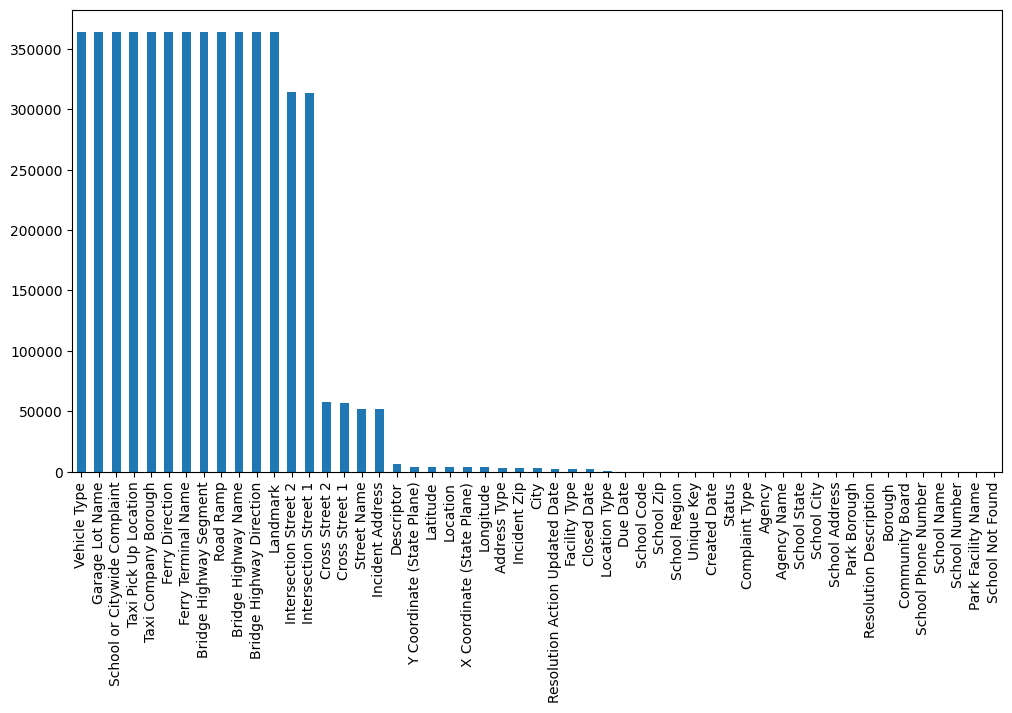

In [6]:
# 2.1 Plot to show the number of null values in each column of dataframe
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))

df.isnull().sum().sort_values(ascending=False).plot(kind='bar')
plt.show()

In [7]:
# 2.2 Missing value treatment
(df.isnull().sum()/len(df))*100

Unique Key                          0.000000
Created Date                        0.000000
Closed Date                         0.653120
Agency                              0.000000
Agency Name                         0.000000
Complaint Type                      0.000000
Descriptor                          1.783255
Location Type                       0.036483
Incident Zip                        0.822366
Incident Address                   14.181283
Street Name                        14.181283
Cross Street 1                     15.686941
Cross Street 2                     15.856187
Intersection Street 1              85.977540
Intersection Street 2              86.144317
Address Type                        0.892039
City                                0.822091
Landmark                           99.897136
Facility Type                       0.655314
Status                              0.000000
Due Date                            0.000823
Resolution Description              0.000000
Resolution

In [8]:
df=df.dropna(axis=1,how='all')


In [9]:
df.shape

(364558, 48)

In [10]:
cols=df.columns[df.isnull().mean() >= 0.99]

In [11]:
cols

Index(['Landmark', 'Bridge Highway Name', 'Bridge Highway Direction',
       'Road Ramp', 'Bridge Highway Segment', 'Ferry Direction',
       'Ferry Terminal Name'],
      dtype='object')

In [12]:
df=df.drop(cols,axis=True)

In [13]:
df.isnull().mean()*100

Unique Key                         0.000000
Created Date                       0.000000
Closed Date                        0.653120
Agency                             0.000000
Agency Name                        0.000000
Complaint Type                     0.000000
Descriptor                         1.783255
Location Type                      0.036483
Incident Zip                       0.822366
Incident Address                  14.181283
Street Name                       14.181283
Cross Street 1                    15.686941
Cross Street 2                    15.856187
Intersection Street 1             85.977540
Intersection Street 2             86.144317
Address Type                       0.892039
City                               0.822091
Facility Type                      0.655314
Status                             0.000000
Due Date                           0.000823
Resolution Description             0.000000
Resolution Action Updated Date     0.658880
Community Board                 

In [14]:
df=df.drop(columns=['Intersection Street 1','Intersection Street 2'],axis=True)

In [15]:
df.isnull().mean()*100

Unique Key                         0.000000
Created Date                       0.000000
Closed Date                        0.653120
Agency                             0.000000
Agency Name                        0.000000
Complaint Type                     0.000000
Descriptor                         1.783255
Location Type                      0.036483
Incident Zip                       0.822366
Incident Address                  14.181283
Street Name                       14.181283
Cross Street 1                    15.686941
Cross Street 2                    15.856187
Address Type                       0.892039
City                               0.822091
Facility Type                      0.655314
Status                             0.000000
Due Date                           0.000823
Resolution Description             0.000000
Resolution Action Updated Date     0.658880
Community Board                    0.000000
Borough                            0.000000
X Coordinate (State Plane)      

In [67]:
df['Incident Address'].fillna('Unknown',inplace=True)
df['Street Name'].fillna('Unknown',inplace=True)
df['Cross Street 1'].fillna('Unknown',inplace=True)
df['Cross Street 2'].fillna('Unknown',inplace=True)
df['Descriptor'].fillna('Unknown',inplace=True)

C:\Users\Ganesh\AppData\Local\Temp\ipykernel_18352\880283166.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Incident Address'].fillna('Unknown',inplace=True)
C:\Users\Ganesh\AppData\Local\Temp\ipykernel_18352\880283166.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

Fo

In [66]:
df=df.dropna(subset=['Closed Date'])
df=df.dropna(subset=['Location Type'])
df=df.dropna(subset=['Incident Zip'])
df=df.dropna(subset=['Address Type'])
df=df.dropna(subset=['City'])
df=df.dropna(subset=['Facility Type'])
df=df.dropna(subset=['Resolution Action Updated Date'])
df=df.dropna(subset=['X Coordinate (State Plane)'])
df=df.dropna(subset=['Y Coordinate (State Plane)'])

In [18]:
df.isnull().mean()*100

Unique Key                        0.0
Created Date                      0.0
Closed Date                       0.0
Agency                            0.0
Agency Name                       0.0
Complaint Type                    0.0
Descriptor                        0.0
Location Type                     0.0
Incident Zip                      0.0
Incident Address                  0.0
Street Name                       0.0
Cross Street 1                    0.0
Cross Street 2                    0.0
Address Type                      0.0
City                              0.0
Facility Type                     0.0
Status                            0.0
Due Date                          0.0
Resolution Description            0.0
Resolution Action Updated Date    0.0
Community Board                   0.0
Borough                           0.0
X Coordinate (State Plane)        0.0
Y Coordinate (State Plane)        0.0
Park Facility Name                0.0
Park Borough                      0.0
School Name 

In [19]:
df.shape

(360004, 39)

In [20]:
df['Created Date']

0         12/31/2015 11:59:45 PM
1         12/31/2015 11:59:44 PM
2         12/31/2015 11:59:29 PM
3         12/31/2015 11:57:46 PM
4         12/31/2015 11:56:58 PM
                   ...          
364553    01/01/2015 12:04:44 AM
364554    01/01/2015 12:04:28 AM
364555    01/01/2015 12:01:30 AM
364556    01/01/2015 12:01:29 AM
364557    01/01/2015 12:00:50 AM
Name: Created Date, Length: 360004, dtype: object

In [40]:
df['Created Date']=pd.to_datetime(df['Created Date'])
df['Closed Date']=pd.to_datetime(df['Closed Date'])

In [22]:
df['Closed Date']

0        2016-01-01 00:55:15
1        2016-01-01 01:26:57
2        2016-01-01 04:51:03
3        2016-01-01 07:43:13
4        2016-01-01 03:24:42
                 ...        
364553   2015-01-01 10:22:31
364554   2015-01-01 02:25:02
364555   2015-01-01 00:20:33
364556   2015-01-01 02:42:22
364557   2015-01-01 02:47:50
Name: Closed Date, Length: 360004, dtype: datetime64[ns]

In [23]:
df['Created Date']

0        2015-12-31 23:59:45
1        2015-12-31 23:59:44
2        2015-12-31 23:59:29
3        2015-12-31 23:57:46
4        2015-12-31 23:56:58
                 ...        
364553   2015-01-01 00:04:44
364554   2015-01-01 00:04:28
364555   2015-01-01 00:01:30
364556   2015-01-01 00:01:29
364557   2015-01-01 00:00:50
Name: Created Date, Length: 360004, dtype: datetime64[ns]

In [24]:
df=df[df['Closed Date']>=df['Created Date']]

In [25]:
df.head()

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,School Code,School Phone Number,School Address,School City,School State,School Zip,School Not Found,Latitude,Longitude,Location
0,32310363,2015-12-31 23:59:45,2016-01-01 00:55:15,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10034.0,71 VERMILYEA AVENUE,...,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,N,40.865682,-73.923501,"(40.86568153633767, -73.92350095571744)"
1,32309934,2015-12-31 23:59:44,2016-01-01 01:26:57,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11105.0,27-07 23 AVENUE,...,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,N,40.775945,-73.915094,"(40.775945312321085, -73.91509393898605)"
2,32309159,2015-12-31 23:59:29,2016-01-01 04:51:03,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,10458.0,2897 VALENTINE AVENUE,...,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,N,40.870325,-73.888525,"(40.870324522111424, -73.88852464418646)"
3,32305098,2015-12-31 23:57:46,2016-01-01 07:43:13,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,10461.0,2940 BAISLEY AVENUE,...,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,N,40.835994,-73.828379,"(40.83599404683083, -73.82837939584206)"
4,32306529,2015-12-31 23:56:58,2016-01-01 03:24:42,NYPD,New York City Police Department,Illegal Parking,Blocked Sidewalk,Street/Sidewalk,11373.0,87-14 57 ROAD,...,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,N,40.733060,-73.874170,"(40.733059618956815, -73.87416975810375)"


In [26]:
# 2.3.1 Calculate the time elapsed in closed and creation date
df['Time_to_Close']=df['Closed Date']-df['Created Date']

In [27]:
df['Time_to_Close']

0        0 days 00:55:30
1        0 days 01:27:13
2        0 days 04:51:34
3        0 days 07:45:27
4        0 days 03:27:44
               ...      
364553   0 days 10:17:47
364554   0 days 02:20:34
364555   0 days 00:19:03
364556   0 days 02:40:53
364557   0 days 02:47:00
Name: Time_to_Close, Length: 360004, dtype: timedelta64[ns]

In [28]:
df['Time_to_close_dayes']=df['Time_to_Close'].dt.total_seconds() / (24*3600)

In [29]:
df['Time_to_close_dayes']

0         0.038542
1         0.060567
2         0.202477
3         0.323229
4         0.144259
            ...   
364553    0.429016
364554    0.097616
364555    0.013229
364556    0.111725
364557    0.115972
Name: Time_to_close_dayes, Length: 360004, dtype: float64

In [30]:
df['Time_to_close_hours']=df['Time_to_Close'].dt.total_seconds() / 3600

In [31]:
df['Time_to_close_hours']

0          0.925000
1          1.453611
2          4.859444
3          7.757500
4          3.462222
            ...    
364553    10.296389
364554     2.342778
364555     0.317500
364556     2.681389
364557     2.783333
Name: Time_to_close_hours, Length: 360004, dtype: float64

In [32]:
# 2.3.2 convert the calculated date to seconds to get representation
df['Elapsed sec']=df['Time_to_Close'].dt.total_seconds()

In [33]:
df['Elapsed sec']

0          3330.0
1          5233.0
2         17494.0
3         27927.0
4         12464.0
           ...   
364553    37067.0
364554     8434.0
364555     1143.0
364556     9653.0
364557    10020.0
Name: Elapsed sec, Length: 360004, dtype: float64

In [34]:
# 2.3.3 View the descriptive statistics for newly created column
df['Elapsed sec'].describe()

count    3.600040e+05
mean     1.508123e+04
std      2.096739e+04
min      6.100000e+01
25%      4.531000e+03
50%      9.606000e+03
75%      1.884500e+04
max      2.134342e+06
Name: Elapsed sec, dtype: float64

In [35]:
# 2.3.4 Check the number of null values in complaint_type and city
df[['Complaint Type','City']].isnull().sum()

Complaint Type    0
City              0
dtype: int64

In [36]:
# 2.3.6 Draw plot for the complaint in each city
df['City'].value_counts()
df['Complaint Type'].value_counts()

Complaint Type
Blocked Driveway             100454
Illegal Parking               91056
Noise - Street/Sidewalk       50788
Noise - Commercial            43623
Derelict Vehicle              21405
Noise - Vehicle               19121
Animal Abuse                  10499
Traffic                        4908
Homeless Encampment            4794
Vending                        4162
Noise - Park                   3994
Drinking                       1399
Noise - House of Worship       1059
Posting Advertisement           678
Urinating in Public             640
Bike/Roller/Skate Chronic       463
Panhandling                     319
Disorderly Youth                314
Illegal Fireworks               167
Graffiti                        157
Squeegee                          4
Name: count, dtype: int64

In [42]:
city_counts=df['City'].value_counts()

In [1]:
city_counts

NameError: name 'city_counts' is not defined

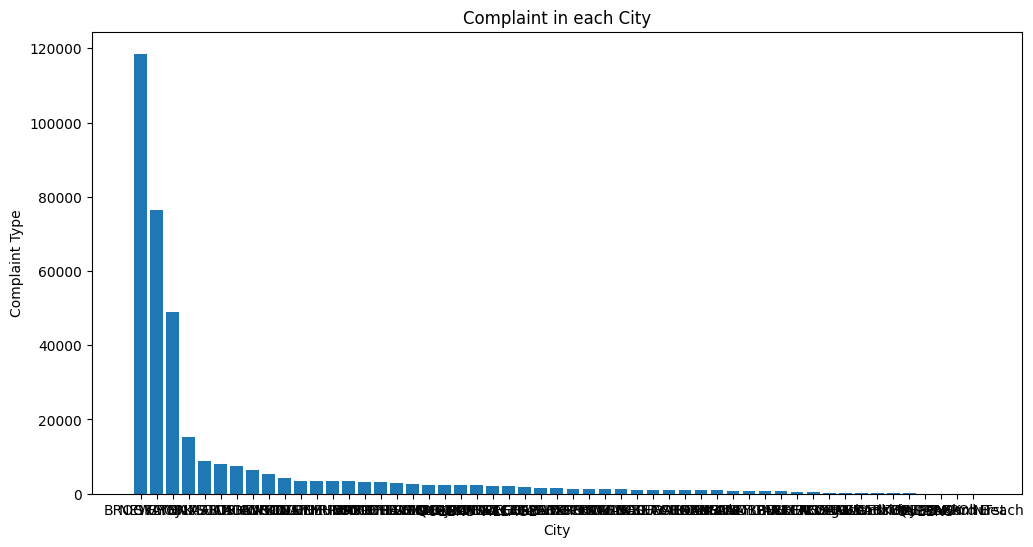

In [41]:
plt.figure(figsize=(12,6))
plt.bar(city_counts.index,city_counts.values)
plt.xlabel('City')
plt.ylabel('Complaint Type')
plt.title('Complaint in each City')
plt.show()

In [44]:
# 2.3.7 Create a scatter and hexabin of the concentration of complaints across Brooklyn
brooklyn_df=df[df['Borough']=='BROOKLYN']

In [46]:
brooklyn_df.head()

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,School State,School Zip,School Not Found,Latitude,Longitude,Location,Time_to_Close,Time_to_close_dayes,Time_to_close_hours,Elapsed sec
5,32306554,2015-12-31 23:56:30,2016-01-01 01:50:11,NYPD,New York City Police Department,Illegal Parking,Posted Parking Sign Violation,Street/Sidewalk,11215.0,260 21 STREET,...,Unspecified,Unspecified,N,40.660823,-73.992568,"(40.66082272389114, -73.99256786342693)",0 days 01:53:41,0.078947,1.894722,6821.0
9,32308391,2015-12-31 23:53:58,2016-01-01 01:17:40,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11219.0,1408 66 STREET,...,Unspecified,Unspecified,N,40.623793,-73.999539,"(40.623793065806524, -73.99953890121567)",0 days 01:23:42,0.058125,1.395000,5022.0
13,32305074,2015-12-31 23:47:58,2016-01-01 08:18:47,NYPD,New York City Police Department,Illegal Parking,Posted Parking Sign Violation,Street/Sidewalk,11208.0,38 COX PLACE,...,Unspecified,Unspecified,N,40.687511,-73.874505,"(40.68751060232221, -73.87450451131276)",0 days 08:30:49,0.354734,8.513611,30649.0
17,32310273,2015-12-31 23:44:52,2016-01-01 00:36:10,NYPD,New York City Police Department,Noise - Commercial,Loud Music/Party,Club/Bar/Restaurant,11217.0,622 DEGRAW STREET,...,Unspecified,Unspecified,N,40.679154,-73.983430,"(40.679154133157326, -73.98342992763081)",0 days 00:51:18,0.035625,0.855000,3078.0
18,32306617,2015-12-31 23:40:59,2016-01-01 02:37:28,NYPD,New York City Police Department,Noise - Commercial,Loud Music/Party,Club/Bar/Restaurant,11234.0,2192 FLATBUSH AVENUE,...,Unspecified,Unspecified,N,40.616550,-73.930202,"(40.61655032892211, -73.93020153359745)",0 days 02:56:29,0.122558,2.941389,10589.0


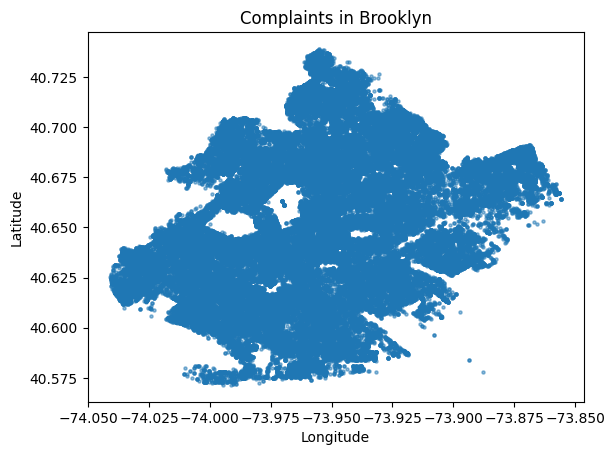

In [47]:
import matplotlib.pyplot as plt
plt.scatter(brooklyn_df['Longitude'],brooklyn_df['Latitude'],s=5,alpha=0.5)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Complaints in Brooklyn')
plt.show()

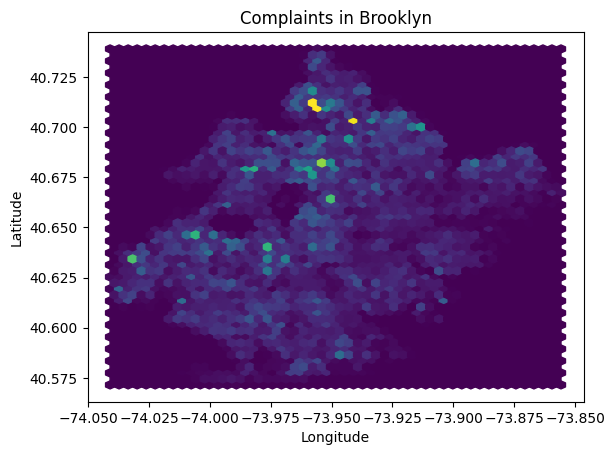

In [50]:
plt.hexbin(brooklyn_df['Longitude'],brooklyn_df['Latitude'],gridsize=50)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Complaints in Brooklyn')
plt.show()

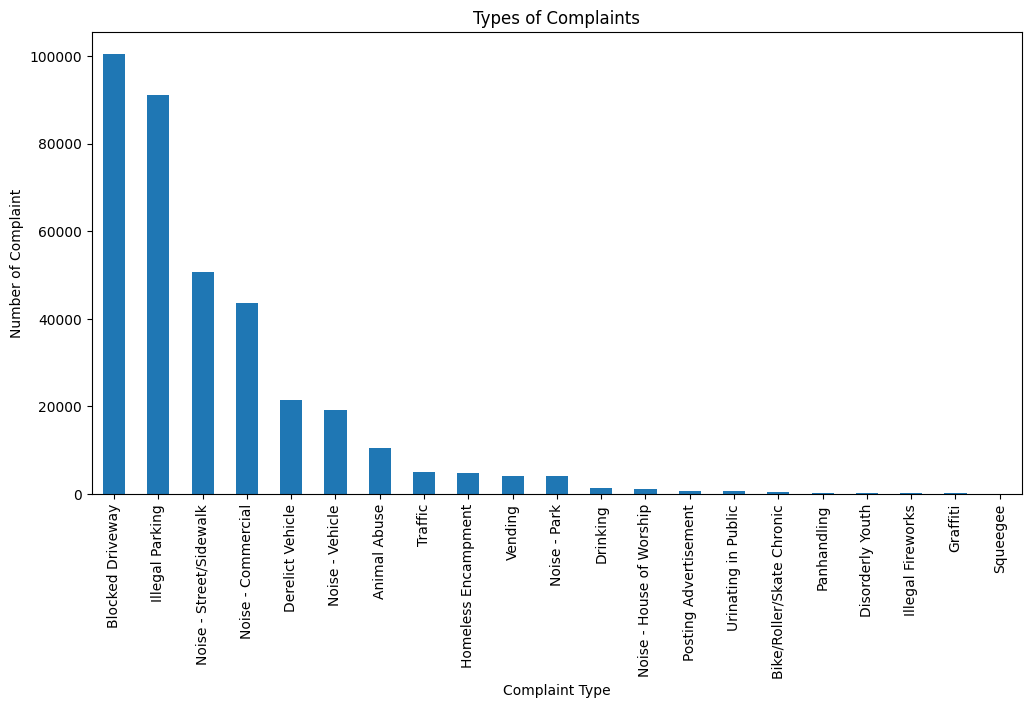

In [54]:
# 3 Find major types of Complaints
# 3.1 Plot a bar graph to show the types of complaints
complaints_counts=df['Complaint Type'].value_counts()
plt.figure(figsize=(12,6))
complaints_counts.plot(kind='bar')
plt.xlabel('Complaint Type')
plt.ylabel('Number of Complaint')
plt.title('Types of Complaints')
plt.show()

In [69]:
# 3.2 Check the frequency of various types of complaints in New York City
nyc=df[df['City']=='NEW YORK']
print(nyc['Complaint Type'].value_counts())

Complaint Type
Noise - Street/Sidewalk      22076
Noise - Commercial           18666
Illegal Parking              14365
Noise - Vehicle               6178
Homeless Encampment           3003
Blocked Driveway              2686
Vending                       2619
Animal Abuse                  1926
Traffic                       1675
Noise - Park                  1200
Derelict Vehicle               685
Drinking                       320
Urinating in Public            264
Bike/Roller/Skate Chronic      249
Noise - House of Worship       217
Panhandling                    203
Disorderly Youth                80
Posting Advertisement           49
Illegal Fireworks               34
Graffiti                        25
Squeegee                         4
Name: count, dtype: int64


In [73]:
# 3.3 Find the top 10 complaints
top_10=df['Complaint Type'].value_counts().head(10)
top_10


Complaint Type
Blocked Driveway           100454
Illegal Parking             91056
Noise - Street/Sidewalk     50788
Noise - Commercial          43623
Derelict Vehicle            21405
Noise - Vehicle             19121
Animal Abuse                10499
Traffic                      4908
Homeless Encampment          4794
Vending                      4162
Name: count, dtype: int64

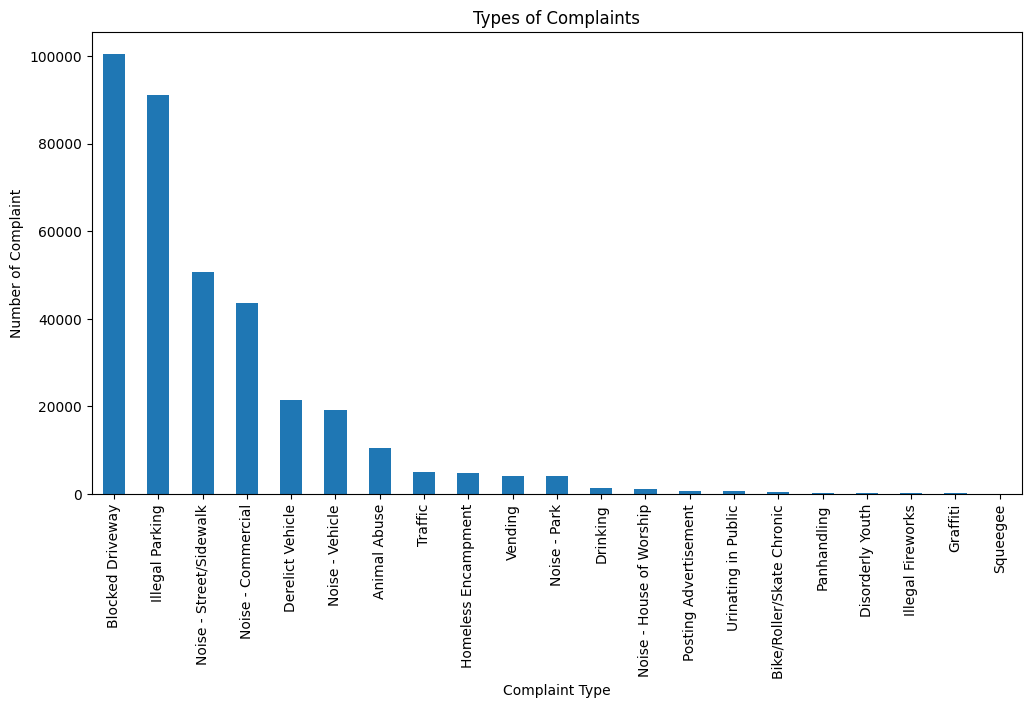

In [75]:
top_10=df['Complaint Type'].value_counts().head(10)
plt.figure(figsize=(12,6))
complaints_counts.plot(kind='bar')
plt.xlabel('Complaint Type')
plt.ylabel('Number of Complaint')
plt.title('Types of Complaints')
plt.show()

In [83]:
# 3.4 Display the various types of complaints in each city
city_complaints=df.groupby(['City','Complaint Type']).size().unstack(fill_value=0)
city_complaints

Complaint Type,Animal Abuse,Bike/Roller/Skate Chronic,Blocked Driveway,Derelict Vehicle,Disorderly Youth,Drinking,Graffiti,Homeless Encampment,Illegal Fireworks,Illegal Parking,...,Noise - House of Worship,Noise - Park,Noise - Street/Sidewalk,Noise - Vehicle,Panhandling,Posting Advertisement,Squeegee,Traffic,Urinating in Public,Vending
City,,,,,,,,,,,,,,,,,,,,,
ARVERNE,46,0,50,32,2,1,1,4,0,62,...,14,2,29,9,1,0,0,1,1,1
ASTORIA,170,16,3436,426,5,43,4,32,4,1337,...,21,64,408,236,2,3,0,58,10,57
Astoria,0,0,159,14,0,0,0,0,0,277,...,0,0,145,0,0,0,0,0,0,0
BAYSIDE,53,0,513,231,2,1,3,2,0,635,...,3,3,17,24,0,0,0,7,0,2
BELLEROSE,15,1,138,120,2,1,0,1,1,131,...,1,1,13,11,1,1,0,9,1,0
BREEZY POINT,2,0,3,3,0,1,0,0,0,16,...,0,0,1,1,0,0,0,0,0,0
BRONX,1965,22,17048,2396,66,205,15,267,24,9853,...,90,523,9118,3544,20,17,0,379,54,431
BROOKLYN,3185,121,36414,6239,79,291,60,935,60,33446,...,387,1557,13943,5932,47,58,0,1203,155,574
CAMBRIA HEIGHTS,15,0,177,148,0,0,0,6,1,113,...,2,0,29,100,0,0,0,7,0,0


In [84]:
# 3.5 Create a DataFrame df_new with cities and columns and complaint types as rows
df_new=city_complaints.T
df_new

City,ARVERNE,ASTORIA,Astoria,BAYSIDE,BELLEROSE,BREEZY POINT,BRONX,BROOKLYN,CAMBRIA HEIGHTS,CENTRAL PARK,...,SAINT ALBANS,SOUTH OZONE PARK,SOUTH RICHMOND HILL,SPRINGFIELD GARDENS,STATEN ISLAND,SUNNYSIDE,WHITESTONE,WOODHAVEN,WOODSIDE,Woodside
Complaint Type,,,,,,,,,,,,,,,,,,,,,
Animal Abuse,46,170,0,53,15,2,1965,3185,15,0,...,43,74,40,42,786,40,43,57,111,0
Bike/Roller/Skate Chronic,0,16,0,0,1,0,22,121,0,0,...,0,1,1,0,9,2,4,2,5,0
Blocked Driveway,50,3436,159,513,138,3,17048,36414,177,0,...,318,1202,1945,330,2844,278,279,1363,2036,27
Derelict Vehicle,32,426,14,231,120,3,2396,6239,148,0,...,248,425,356,266,2180,17,278,369,297,8
Disorderly Youth,2,5,0,2,2,0,66,79,0,0,...,1,2,2,0,25,2,1,0,1,0
Drinking,1,43,0,1,1,1,205,291,0,0,...,3,14,25,6,188,12,3,4,15,0
Graffiti,1,4,0,3,0,0,15,60,0,0,...,0,2,0,0,6,1,1,0,4,0
Homeless Encampment,4,32,0,2,1,0,267,935,6,0,...,11,5,12,7,77,12,0,10,36,0
Illegal Fireworks,0,4,0,0,1,0,24,60,1,0,...,0,1,2,1,11,0,1,0,1,0


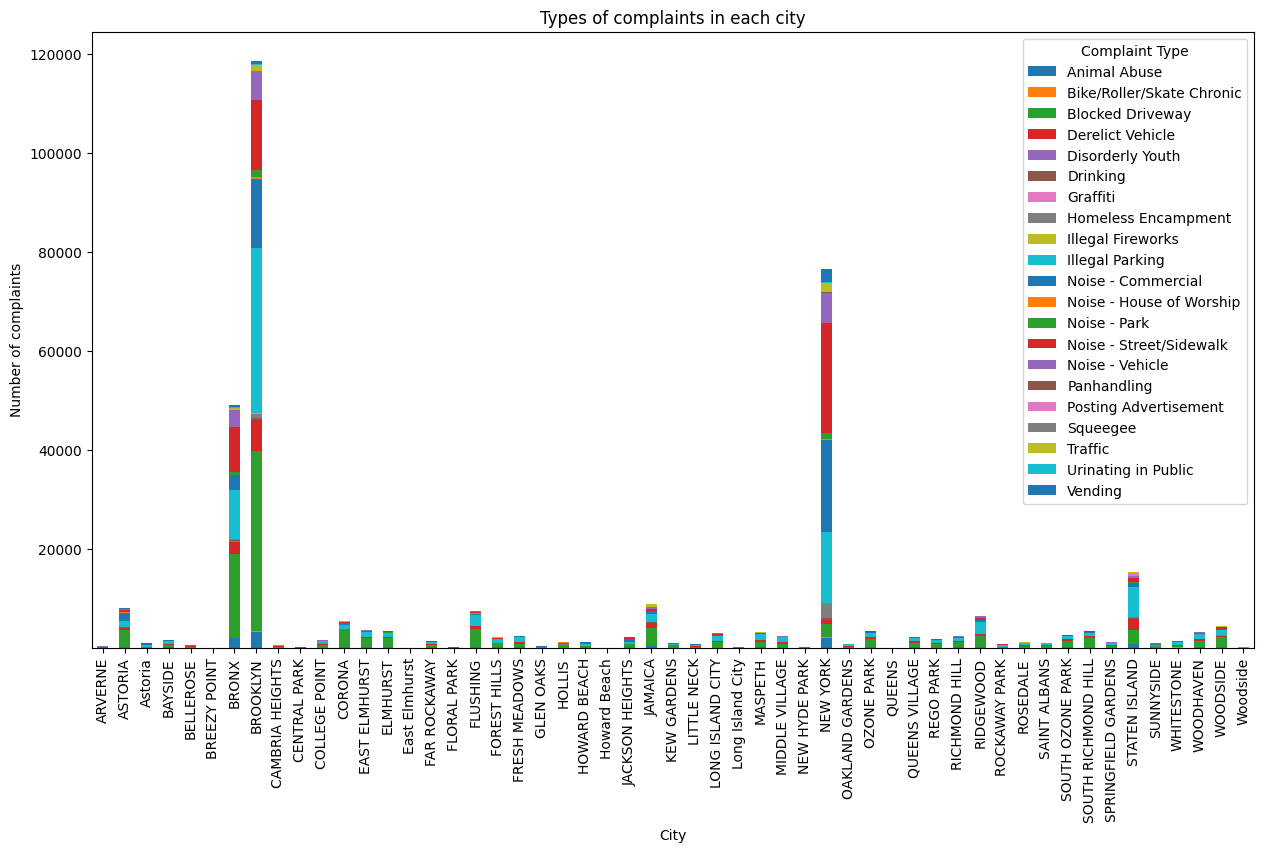

In [85]:
# 4.1 
city_complaints.plot(kind='bar',stacked=True,figsize=(15,8))
plt.xlabel('City')
plt.ylabel('Number of complaints')
plt.title('Types of complaints in each city')
plt.show()

In [89]:
# 4.2 Sort the complaint types based on the average request_closing_time
avg_time=df.groupby(['City','Complaint Type'])['Time_to_close_hours'].mean().reset_index()
avg_time

,City,Complaint Type,Time_to_close_hours
0,ARVERNE,Animal Abuse,2.333110
1,ARVERNE,Blocked Driveway,2.310789
2,ARVERNE,Derelict Vehicle,3.165000
3,ARVERNE,Disorderly Youth,3.591250
4,ARVERNE,Drinking,0.238611
...,...,...,...
771,Woodside,Blocked Driveway,4.323940
772,Woodside,Derelict Vehicle,5.554028
773,Woodside,Illegal Parking,4.803739
774,Woodside,Noise - Commercial,2.394167


In [91]:
avg_time_sorted=avg_time.sort_values(by='Time_to_close_hours',ascending=False)
avg_time_sorted

,City,Complaint Type,Time_to_close_hours
524,QUEENS VILLAGE,Graffiti,53.331944
63,BELLEROSE,Homeless Encampment,39.147222
652,SOUTH RICHMOND HILL,Bike/Roller/Skate Chronic,30.910278
482,OAKLAND GARDENS,Homeless Encampment,28.654444
681,SPRINGFIELD GARDENS,Posting Advertisement,19.502917
...,...,...,...
519,QUEENS,Urinating in Public,0.340556
497,OZONE PARK,Illegal Fireworks,0.330833
170,EAST ELMHURST,Bike/Roller/Skate Chronic,0.252222
584,RIDGEWOOD,Posting Advertisement,0.248611


In [92]:
# See whether the average response time across different complaint types is similar (overall)
overall_avg=df.groupby('Complaint Type')['Time_to_close_hours'].mean().sort_values()
overall_avg

Complaint Type
Posting Advertisement        2.024214
Illegal Fireworks            2.811763
Noise - Commercial           3.067349
Noise - House of Worship     3.169554
Noise - Park                 3.387847
Noise - Street/Sidewalk      3.393476
Disorderly Youth             3.443265
Traffic                      3.445367
Noise - Vehicle              3.494745
Bike/Roller/Skate Chronic    3.594999
Urinating in Public          3.599182
Drinking                     3.834974
Vending                      3.987574
Squeegee                     4.044514
Panhandling                  4.233788
Homeless Encampment          4.268664
Illegal Parking              4.328599
Blocked Driveway             4.504998
Animal Abuse                 5.010542
Graffiti                     6.465651
Derelict Vehicle             7.024991
Name: Time_to_close_hours, dtype: float64

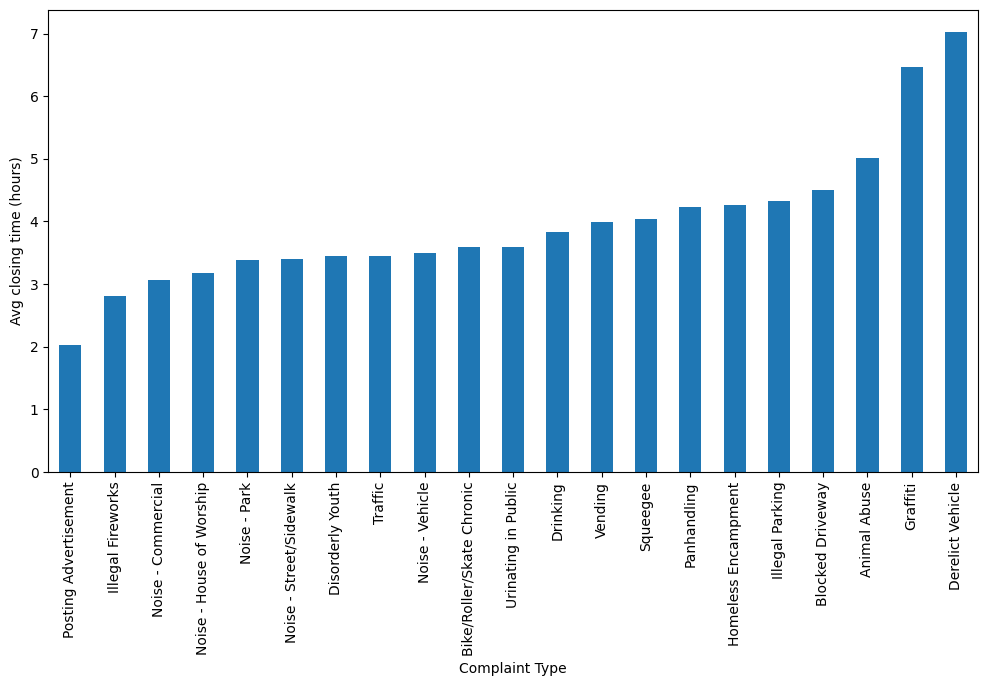

In [93]:
# 5.1 Visualize the average of time_to_close_hours
overall_avg.plot(kind='bar',figsize=(12,6))
plt.xlabel('Complaint Type')
plt.ylabel('Avg closing time (hours)')
plt.show()


In [95]:
# 6 Identify significant variables using p-values
from scipy.stats import f_oneway
groups=[group['Time_to_close_hours']
        for name,group in df.groupby('Complaint Type')
       ]
stat,p_value=f_oneway(*groups)
print('P-value:',p_value)

P-value: 0.0


In [96]:
# Perform Kruskal-Wallis test
from scipy.stats import kruskal
stat,p_value=kruskal(*groups)
print('Kruskal Test p-value:',p_value)

Kruskal Test p-value: 0.0


In [ ]:
# 8 Observation
The p-value obtained from both ANOVA and Kruskal-Wallis test is extremely small (close to 0) which is less then the significance level
of 0.5 Therefore we reject the null hypothesis